Notebooken ekstraherer pixel intensiteter fra hyperspektrale billeder:

Måleposition: $X = 623$ og $Y = 595$.  
  

Exposure time: $48.29 \ \text{ms}$

-------

Transmissionskonstanter for kamera, linser, globar ved alle relevante bølgelængder:

$$
I_{\text{Hyperspekt. output}}​(\lambda) = I_{\text{glo-bar}}​(\lambda) \cdot T_{\text{finger}}(\lambda) \cdot T_{\text{linser}}(\lambda) \cdot T_{\text{filter}}(\lambda) \cdot T_{\text{kamera}}(\lambda)
$$

Isoleret for fingerens relative transmission:

$$
I_{\text{hyperspekt. output}}(\lambda)=
\frac{
\operatorname{median}_{(x,y)\in ROI}\left(I_{\text{finger}}(x,y,\lambda)\right)-
\operatorname{median}\left(I_{\text{dark}}(x,y,\lambda)\right)
}{t_{\text{exp}}}
$$

$$
Finger_{\text{korr}}(\lambda)=
\frac{I_{\text{hyperspekt. output}}(\lambda)}{E_{\text{glo-bar}}(\lambda) \cdot
T_{\text{linse1}}(\lambda) \cdot
T_{\text{linse2}}(\lambda) \cdot
T_{\text{linse3}}(\lambda) \cdot
T_{\text{filter}}(\lambda) \cdot
QE_{\text{kamera}}(\lambda)}
$$

Da den absolutte geometri ikke er kendt, normaliseres signalet til 940 nm:

$$
T_{\text{finger,rel}}(\lambda)=
\frac{Finger_{\text{Korr}}(\lambda)}{Finger_{\text{korr}}(940\,\text{nm})}
$$


For alle de 6 relevante bølgelængder:

||800nm|810nm|820nm|930nm|940nm|950nm|
|-|-|-|-|-|-|-|
|Stage pos.|5.880 mm|5.284 mm|4.688 mm|-1.871 mm|-2.467 mm|-3.063 mm|
|Hyperspekt. output $[\text{counts}/\text{s}]$|$1052.6$|$1157.9$|$1263.2$|$2000.0$|$1789.5$|$1263.2$|
|glo-bar  $\left [\frac{\text{Watt}}{m^2} \right ]$|$1.6630$|$1.8314$|$2.0042$|$4.8737$|$5.2153$|$5.5886$|
|linse 1 (AC254-030-AB)|$0.9893$|$0.9893$|$0.9893$|$0.9892$|$0.9892$|$0.9892$|
|linse 2 (AC127-025-AB)|$0.9885$|$0.9873$|$0.9865$|$0.9730$|$0.9715$|$0.9700$|
|linse 3 (AC127-050-AB)|$0.9885$|$0.9875$|$0.9866$|$0.9728$|$0.9715$|$0.9700$|
|filter|$0.83$|$0.84$|$0.85$|$0.93$|$0.925$|$0.92$|
|kamera (quantum efficiency)|$0.48$|$0.47$|$0.45$|$0.24$|$0.22$|$0.18$|


## Mørkekorrigeret pixelintensitet

For hver bølgelængde læses fingerbilledet og det tilhørende mørkebillede. Mørkemålingerne var oprindeligt 1280 x 1024 px, mens fingerbillederne er 1280 x 690 px. Derfor er mørkemålingerne nu centreret beskåret med 167 px fra toppen og 167 px fra bunden, så mørke- og fingerbillederne har samme dimensioner.

Den ønskede korrektion er:

$$I_{\text{korrigeret}}(x,y,\lambda) = I_{\text{finger}}(x,y,\lambda) - I_{\text{mørke}}(x,y,\lambda)$$

Når billederne har samme dimensioner, kan samme ROI-koordinater bruges direkte i begge billeder. I NumPy/Python-billedarrays er indeksrækkefølgen `[y, x]`, så målepositionen `X = 623`, `Y = 595` læses som `image[595, 623]`.


## Mean

In [54]:
from pathlib import Path
import numpy as np
import pandas as pd
import tifffile as tiff

roi_x_venstre, roi_x_højre = 280, 800
roi_y_øverste, roi_y_nederste = 200, 600

wavelengths = [800, 810, 820, 930, 940, 950]

data_dir = Path("/home/daniel/Desktop/Uni/6 Semester/Bachelorprojekt/bachelorprojekt/data/raw/daniel")

glo_bar = {
    800: 1.6630,
    810: 1.8314,
    820: 2.0042,
    930: 4.8737,
    940: 5.2153,
    950: 5.5886,
}

lens1 = {
    800: 0.9893,
    810: 0.9893,
    820: 0.9893,
    930: 0.9892,
    940: 0.9892,
    950: 0.9892,
}

lens2 = {
    800: 0.9885,
    810: 0.9873,
    820: 0.9865,
    930: 0.9730,
    940: 0.9715,
    950: 0.9700,
}

lens3 = {
    800: 0.9885,
    810: 0.9875,
    820: 0.9866,
    930: 0.9728,
    940: 0.9715,
    950: 0.9700,
}

filter_T = {
    800: 0.83,
    810: 0.84,
    820: 0.85,
    930: 0.93,
    940: 0.925,
    950: 0.92,
}

camera_QE = {
    800: 0.48,
    810: 0.47,
    820: 0.45,
    930: 0.24,
    940: 0.22,
    950: 0.18,
}

def read_intensity_image(path):
    img = tiff.imread(path).astype(np.float64)

    if img.ndim == 3:
        img = img[..., :3].mean(axis=2)

    return img

rows = []

for lam in wavelengths:
    finger = read_intensity_image(data_dir / f"finger{lam}nm.tif")
    dark = read_intensity_image(data_dir / f"dark{lam}nm.tif")

    assert finger.shape == dark.shape, (
        f"Finger- og mørkebillede for {lam} nm har forskellige dimensioner: "
        f"{finger.shape} og {dark.shape}."
    )

    finger_roi = finger[roi_y_øverste:roi_y_nederste, roi_x_venstre:roi_x_højre]
    dark_roi = dark[roi_y_øverste:roi_y_nederste, roi_x_venstre:roi_x_højre]
    finger_roi_mean = np.mean(finger_roi)
    dark_mean = np.mean(dark_roi)

    dark_corrected = finger_roi_mean - dark_mean

    instrument_factor_G = (
        glo_bar[lam]
        * lens1[lam]
        * lens2[lam]
        * lens3[lam]
        * filter_T[lam]
        * camera_QE[lam]
    )

    S_corr = dark_corrected / instrument_factor_G

    rows.append({
        "Bølgelængde_nm": lam,
        "finger_roi_median": finger_roi_mean,
        "Mørkemåling_ROI_median": dark_mean,
        "Mørkekorrigeret_counts": dark_corrected,
        "Korrigeret_sample": S_corr,
    })

df_roi_520x400_mean = pd.DataFrame(rows)
S_corr_940_mean = df_roi_520x400_mean.loc[df_roi_520x400_mean["Bølgelængde_nm"] == 940, "Korrigeret_sample"].iloc[0]
df_roi_520x400_mean["relativ_finger_transmission_til_940"] = df_roi_520x400_mean["Korrigeret_sample"] / S_corr_940_mean
    
df_roi_520x400_mean

,Bølgelængde_nm,finger_roi_median,Mørkemåling_ROI_median,Mørkekorrigeret_counts,Korrigeret_sample,relativ_finger_transmission_til_940
0,800,20.504178,5.748543,14.755635,23.039071,1.598151
1,810,21.732846,5.870149,15.862697,22.745863,1.577812
2,820,22.216697,5.836543,16.380154,22.191122,1.539331
3,930,19.353615,3.144563,16.209053,15.914176,1.103918
4,940,16.848510,2.564154,14.284356,14.416082,1.000000
5,950,13.356779,2.096986,11.259793,13.071923,0.906760


---
## Gentaget pixelintensitetsberegning med ROI på 47 x 360 px

ROI'en er placeret ud fra de angivne hjørner:

- Nederste venstre hjørne: $(562, 503)$
- Nederste højre hjørne: $(609, 503)$
- Øverste højre hjørne: $(609, 142)$
- Øverste venstre hjørne: $(562, 142)$

For at få en præcis ROI på 47 px i bredden og 360 px i højden bruges NumPy-udsnittet `x = 562:609` og `y = 143:503`. Højre og nederste grænse er eksklusive i NumPy, og den første inkluderede pixelrække ligger derfor lige under den øverste kant.

Mørkemålingerne er centreret beskåret til samme 1280 x 690 px dimensioner som fingerbillederne, så samme ROI-koordinater bruges direkte for både finger- og mørkemåling.


In [55]:
# Gentaget mørkekorrigeret pixelintensitetsberegning for den nye ROI.
roi_x_venstre = 562
roi_x_højre = 609
roi_y_øverste = 143
roi_y_nederste = 503

roi_bredde_px = roi_x_højre - roi_x_venstre
roi_højde_px = roi_y_nederste - roi_y_øverste

roi_rækker = []

for bølgelængde in wavelengths:
    finger = read_intensity_image(data_dir / f"finger{bølgelængde}nm.tif")
    mørke = read_intensity_image(data_dir / f"dark{bølgelængde}nm.tif")

    finger_roi = finger[roi_y_øverste:roi_y_nederste, roi_x_venstre:roi_x_højre]
    mørke_roi = mørke[roi_y_øverste:roi_y_nederste, roi_x_venstre:roi_x_højre]

    finger_roi_median = np.mean(finger_roi)
    mørke_roi_median = np.mean(mørke_roi)
    mørkekorrigeret_counts = finger_roi_median - mørke_roi_median

    instrumentfaktor = (
        glo_bar[bølgelængde]
        * lens1[bølgelængde]
        * lens2[bølgelængde]
        * lens3[bølgelængde]
        * filter_T[bølgelængde]
        * camera_QE[bølgelængde]
    )

    korrigeret_sample = mørkekorrigeret_counts / instrumentfaktor

    roi_rækker.append({
        "Bølgelængde_nm": bølgelængde,
        "finger_ROI_median": finger_roi_median,
        "mørke_ROI_median": mørke_roi_median,
        "mørkekorrigeret_counts": mørkekorrigeret_counts,
        "korrigeret_sample": korrigeret_sample,
    })

df_roi_47x360_ny_roi_mean = pd.DataFrame(roi_rækker)
korrigeret_sample_940_mean = df_roi_47x360_ny_roi_mean.loc[
    df_roi_47x360_ny_roi_mean["Bølgelængde_nm"] == 940, "korrigeret_sample"
].iloc[0]

df_roi_47x360_ny_roi_mean["relativ_fingertransmission_til_940_ny_roi"] = (
    df_roi_47x360_ny_roi_mean["korrigeret_sample"] / korrigeret_sample_940_mean
)


df_roi_47x360_ny_roi_mean

,Bølgelængde_nm,finger_ROI_median,mørke_ROI_median,mørkekorrigeret_counts,korrigeret_sample,relativ_fingertransmission_til_940_ny_roi
0,800,22.040839,4.889243,17.151596,26.780063,1.593891
1,810,23.556678,4.974527,18.582151,26.645347,1.585873
2,820,24.339894,4.942790,19.397104,26.278356,1.564030
3,930,21.035284,2.478369,18.556915,18.219325,1.084374
4,940,18.321040,1.672872,16.648168,16.801692,1.000000
5,950,14.026300,1.322104,12.704196,14.748785,0.877815


## Median

In [56]:
from pathlib import Path
import numpy as np
import pandas as pd
import tifffile as tiff

roi_x_venstre, roi_x_højre = 280, 800
roi_y_øverste, roi_y_nederste = 200, 600

wavelengths = [800, 810, 820, 930, 940, 950]

data_dir = Path("/home/daniel/Desktop/Uni/6 Semester/Bachelorprojekt/bachelorprojekt/data/raw/daniel")

glo_bar = {
    800: 1.6630,
    810: 1.8314,
    820: 2.0042,
    930: 4.8737,
    940: 5.2153,
    950: 5.5886,
}

lens1 = {
    800: 0.9893,
    810: 0.9893,
    820: 0.9893,
    930: 0.9892,
    940: 0.9892,
    950: 0.9892,
}

lens2 = {
    800: 0.9885,
    810: 0.9873,
    820: 0.9865,
    930: 0.9730,
    940: 0.9715,
    950: 0.9700,
}

lens3 = {
    800: 0.9885,
    810: 0.9875,
    820: 0.9866,
    930: 0.9728,
    940: 0.9715,
    950: 0.9700,
}

filter_T = {
    800: 0.83,
    810: 0.84,
    820: 0.85,
    930: 0.93,
    940: 0.925,
    950: 0.92,
}

camera_QE = {
    800: 0.48,
    810: 0.47,
    820: 0.45,
    930: 0.24,
    940: 0.22,
    950: 0.18,
}

def read_intensity_image(path):
    img = tiff.imread(path).astype(np.float64)

    if img.ndim == 3:
        img = img[..., :3].mean(axis=2)

    return img

rows = []

for lam in wavelengths:
    finger = read_intensity_image(data_dir / f"finger{lam}nm.tif")
    dark = read_intensity_image(data_dir / f"dark{lam}nm.tif")

    assert finger.shape == dark.shape, (
        f"Finger- og mørkebillede for {lam} nm har forskellige dimensioner: "
        f"{finger.shape} og {dark.shape}."
    )

    finger_roi = finger[roi_y_øverste:roi_y_nederste, roi_x_venstre:roi_x_højre]
    dark_roi = dark[roi_y_øverste:roi_y_nederste, roi_x_venstre:roi_x_højre]
    finger_roi_median = np.median(finger_roi)
    dark_median = np.median(dark_roi)

    dark_corrected = finger_roi_median - dark_median

    instrument_factor_G = (
        glo_bar[lam]
        * lens1[lam]
        * lens2[lam]
        * lens3[lam]
        * filter_T[lam]
        * camera_QE[lam]
    )

    S_corr = dark_corrected / instrument_factor_G

    rows.append({
        "Bølgelængde_nm": lam,
        "finger_roi_median": finger_roi_median,
        "Mørkemåling_ROI_median": dark_median,
        "Mørkekorrigeret_counts": dark_corrected,
        "Korrigeret_sample": S_corr,
    })

df_roi_520x400_median = pd.DataFrame(rows)
S_corr_940_median = df_roi_520x400_median.loc[df_roi_520x400_median["Bølgelængde_nm"] == 940, "Korrigeret_sample"].iloc[0]
df_roi_520x400_median["relativ_finger_transmission_til_940"] = df_roi_520x400_median["Korrigeret_sample"] / S_corr_940_median
    
df_roi_520x400_median


,Bølgelængde_nm,finger_roi_median,Mørkemåling_ROI_median,Mørkekorrigeret_counts,Korrigeret_sample,relativ_finger_transmission_til_940
0,800,21.0,5.0,16.0,24.981991,1.650248
1,810,22.0,5.0,17.0,24.376667,1.610262
2,820,23.0,5.0,18.0,24.385620,1.610853
3,930,19.0,3.0,16.0,15.708926,1.037692
4,940,17.0,2.0,15.0,15.138325,1.000000
5,950,13.0,2.0,11.0,12.770319,0.843575


## Gentaget pixelintensitetsberegning med ROI på 47 x 360 px

ROI'en er placeret ud fra de angivne hjørner:

- Nederste venstre hjørne: $(562, 503)$
- Nederste højre hjørne: $(609, 503)$
- Øverste højre hjørne: $(609, 142)$
- Øverste venstre hjørne: $(562, 142)$

For at få en præcis ROI på 47 px i bredden og 360 px i højden bruges NumPy-udsnittet `x = 562:609` og `y = 143:503`. Højre og nederste grænse er eksklusive i NumPy, og den første inkluderede pixelrække ligger derfor lige under den øverste kant.

Mørkemålingerne er centreret beskåret til samme 1280 x 690 px dimensioner som fingerbillederne, så samme ROI-koordinater bruges direkte for både finger- og mørkemåling.


In [57]:
# Gentaget mørkekorrigeret pixelintensitetsberegning for den nye ROI.
roi_x_venstre = 562
roi_x_højre = 609
roi_y_øverste = 143
roi_y_nederste = 503

roi_bredde_px = roi_x_højre - roi_x_venstre
roi_højde_px = roi_y_nederste - roi_y_øverste

roi_rækker = []

for bølgelængde in wavelengths:
    finger = read_intensity_image(data_dir / f"finger{bølgelængde}nm.tif")
    mørke = read_intensity_image(data_dir / f"dark{bølgelængde}nm.tif")

    finger_roi = finger[roi_y_øverste:roi_y_nederste, roi_x_venstre:roi_x_højre]
    mørke_roi = mørke[roi_y_øverste:roi_y_nederste, roi_x_venstre:roi_x_højre]

    finger_roi_median = np.median(finger_roi)
    mørke_roi_median = np.median(mørke_roi)
    mørkekorrigeret_counts = finger_roi_median - mørke_roi_median

    instrumentfaktor = (
        glo_bar[bølgelængde]
        * lens1[bølgelængde]
        * lens2[bølgelængde]
        * lens3[bølgelængde]
        * filter_T[bølgelængde]
        * camera_QE[bølgelængde]
    )

    korrigeret_sample = mørkekorrigeret_counts / instrumentfaktor

    roi_rækker.append({
        "Bølgelængde_nm": bølgelængde,
        "finger_ROI_median": finger_roi_median,
        "mørke_ROI_median": mørke_roi_median,
        "mørkekorrigeret_counts": mørkekorrigeret_counts,
        "korrigeret_sample": korrigeret_sample,
    })

df_roi_47x360_ny_roi_median = pd.DataFrame(roi_rækker)
korrigeret_sample_940_median = df_roi_47x360_ny_roi_median.loc[
    df_roi_47x360_ny_roi_median["Bølgelængde_nm"] == 940, "korrigeret_sample"
].iloc[0]

df_roi_47x360_ny_roi_median["relativ_fingertransmission_til_940_ny_roi"] = (
    df_roi_47x360_ny_roi_median["korrigeret_sample"] / korrigeret_sample_940_median
)


df_roi_47x360_ny_roi_median


,Bølgelængde_nm,finger_ROI_median,mørke_ROI_median,mørkekorrigeret_counts,korrigeret_sample,relativ_fingertransmission_til_940_ny_roi
0,800,22.0,4.0,18.0,28.104740,1.740496
1,810,24.0,4.0,20.0,28.678431,1.776024
2,820,25.0,4.0,21.0,28.449890,1.761871
3,930,21.0,2.0,19.0,18.654349,1.155244
4,940,18.0,2.0,16.0,16.147547,1.000000
5,950,14.0,1.0,13.0,15.092195,0.934643


---------


### Firkantet ROI - Median - (520x400) 

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>Bølgelængde_nm</th>
      <th>finger_roi_median</th>
      <th>Mørke_ROI_median</th>
      <th>Mørkekorrigeret_counts</th>
      <th>Korrigeret_sample</th>
      <th>relativ_finger_transmission_til_940</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>800</td>
      <td>21.0</td>
      <td>5.0</td>
      <td>16.0</td>
      <td>24.981991</td>
      <td>1.650248</td>
    </tr>
    <tr>
      <td>810</td>
      <td>22.0</td>
      <td>5.0</td>
      <td>17.0</td>
      <td>24.376667</td>
      <td>1.610262</td>
    </tr>
    <tr>
      <td>820</td>
      <td>23.0</td>
      <td>5.0</td>
      <td>18.0</td>
      <td>24.385620</td>
      <td>1.610853</td>
    </tr>
    <tr>
      <td>930</td>
      <td>19.0</td>
      <td>3.0</td>
      <td>16.0</td>
      <td>15.708926</td>
      <td>1.037692</td>
    </tr>
    <tr>
      <td>940</td>
      <td>17.0</td>
      <td>2.0</td>
      <td>15.0</td>
      <td>15.138325</td>
      <td>1.000000</td>
    </tr>
    <tr>
      <td>950</td>
      <td>13.0</td>
      <td>2.0</td>
      <td>11.0</td>
      <td>12.770319</td>
      <td>0.843575</td>
    </tr>
  </tbody>
</table>
</div>

### Søjle ROI - Median - (47x360)

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>Bølgelængde_nm</th>
      <th>finger_ROI_median</th>
      <th>mørke_ROI_median</th>
      <th>mørkekorrigeret_counts</th>
      <th>korrigeret_sample</th>
      <th>relativ fingertransmission til_940</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>800</td>
      <td>22.0</td>
      <td>4.0</td>
      <td>18.0</td>
      <td>28.104740</td>
      <td>1.740496</td>
    </tr>
    <tr>
      <td>810</td>
      <td>24.0</td>
      <td>4.0</td>
      <td>20.0</td>
      <td>28.678431</td>
      <td>1.776024</td>
    </tr>
    <tr>
      <td>820</td>
      <td>25.0</td>
      <td>4.0</td>
      <td>21.0</td>
      <td>28.449890</td>
      <td>1.761871</td>
    </tr>
    <tr>
      <td>930</td>
      <td>21.0</td>
      <td>2.0</td>
      <td>19.0</td>
      <td>18.654349</td>
      <td>1.155244</td>
    </tr>
    <tr>
      <td>940</td>
      <td>18.0</td>
      <td>2.0</td>
      <td>16.0</td>
      <td>16.147547</td>
      <td>1.000000</td>
    </tr>
    <tr>
      <td>950</td>
      <td>14.0</td>
      <td>1.0</td>
      <td>13.0</td>
      <td>15.092195</td>
      <td>0.934643</td>
    </tr>
  </tbody>
</table>
</div>

### Firkantet ROI - Mean - (520x400) 

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>Bølgelængde_nm</th>
      <th>finger_roi_median</th>
      <th>Mørke_ROI_median</th>
      <th>Mørkekorrigeret_counts</th>
      <th>Korrigeret_sample</th>
      <th>relativ_finger_transmission_til_940</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>800</td>
      <td>20.504178</td>
      <td>5.748543</td>
      <td>14.755635</td>
      <td>23.039071</td>
      <td>1.598151</td>
    </tr>
    <tr>
      <td>810</td>
      <td>21.732846</td>
      <td>5.870149</td>
      <td>15.862697</td>
      <td>22.745863</td>
      <td>1.577812</td>
    </tr>
    <tr>
      <td>820</td>
      <td>22.216697</td>
      <td>5.836543</td>
      <td>16.380154</td>
      <td>22.191122</td>
      <td>1.539331</td>
    </tr>
    <tr>
      <td>930</td>
      <td>19.353615</td>
      <td>3.144563</td>
      <td>16.209053</td>
      <td>15.914176</td>
      <td>1.103918</td>
    </tr>
    <tr>
      <td>940</td>
      <td>16.848510</td>
      <td>2.564154</td>
      <td>14.284356</td>
      <td>14.416082</td>
      <td>1.000000</td>
    </tr>
    <tr>
      <td>950</td>
      <td>13.356779</td>
      <td>2.096986</td>
      <td>11.259793</td>
      <td>13.071923</td>
      <td>0.906760</td>
    </tr>
  </tbody>
</table>
</div>

### Søjle ROI - Mean - (47x360)

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>Bølgelængde_nm</th>
      <th>finger_ROI_median</th>
      <th>mørke_ROI_median</th>
      <th>mørkekorrigeret_counts</th>
      <th>korrigeret_sample</th>
      <th>relativ_fingertransmission_til_940_ny_roi</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>800</td>
      <td>22.040839</td>
      <td>4.889243</td>
      <td>17.151596</td>
      <td>26.780063</td>
      <td>1.593891</td>
    </tr>
    <tr>
      <td>810</td>
      <td>23.556678</td>
      <td>4.974527</td>
      <td>18.582151</td>
      <td>26.645347</td>
      <td>1.585873</td>
    </tr>
    <tr>
      <td>820</td>
      <td>24.339894</td>
      <td>4.942790</td>
      <td>19.397104</td>
      <td>26.278356</td>
      <td>1.564030</td>
    </tr>
    <tr>
      <td>930</td>
      <td>21.035284</td>
      <td>2.478369</td>
      <td>18.556915</td>
      <td>18.219325</td>
      <td>1.084374</td>
    </tr>
    <tr>
      <td>940</td>
      <td>18.321040</td>
      <td>1.672872</td>
      <td>16.648168</td>
      <td>16.801692</td>
      <td>1.000000</td>
    </tr>
    <tr>
      <td>950</td>
      <td>14.026300</td>
      <td>1.322104</td>
      <td>12.704196</td>
      <td>14.748785</td>
      <td>0.877815</td>
    </tr>
  </tbody>
</table>
</div>

### Sammenligningsplot

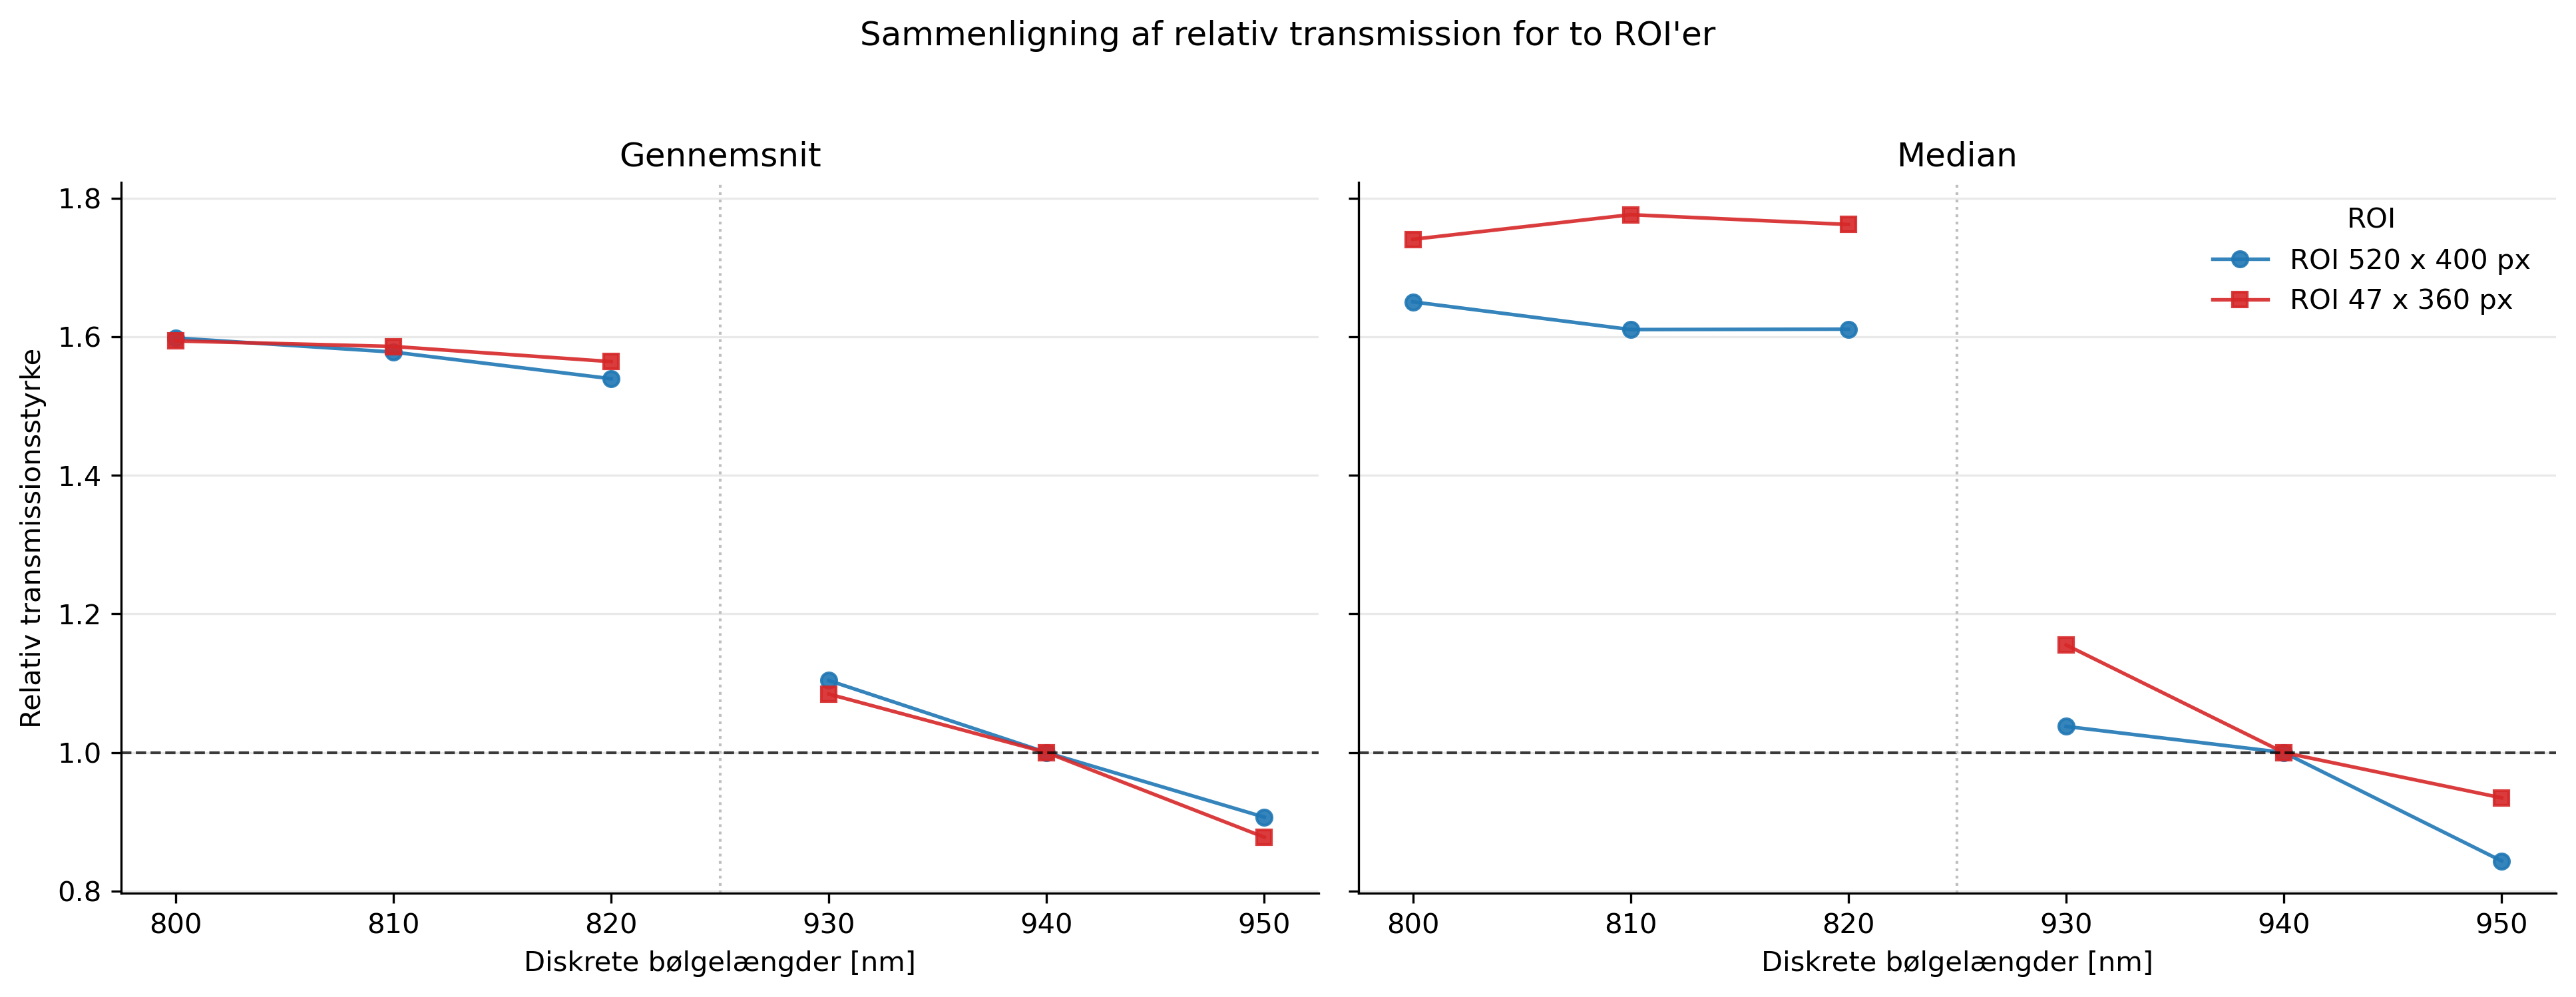

In [69]:
import matplotlib.pyplot as plt

bølgelængder = [800, 810, 820, 930, 940, 950]
x_positioner = list(range(len(bølgelængder)))
x_lookup = dict(zip(bølgelængder, x_positioner))
grupper = [[800, 810, 820], [930, 940, 950]]

plotdata = {
    "Gennemsnit": [
        (
            df_roi_520x400_mean,
            "relativ_finger_transmission_til_940",
            "ROI 520 x 400 px",
            "tab:blue",
            "o",
        ),
        (
            df_roi_47x360_ny_roi_mean,
            "relativ_fingertransmission_til_940_ny_roi",
            "ROI 47 x 360 px",
            "tab:red",
            "s",
        ),
    ],
    "Median": [
        (
            df_roi_520x400_median,
            "relativ_finger_transmission_til_940",
            "ROI 520 x 400 px",
            "tab:blue",
            "o",
        ),
        (
            df_roi_47x360_ny_roi_median,
            "relativ_fingertransmission_til_940_ny_roi",
            "ROI 47 x 360 px",
            "tab:red",
            "s",
        ),
    ],
}

fig, akser = plt.subplots(1, 2, figsize=(13, 4.8), dpi=300, sharey=True)

for akse, (metode, datasæt) in zip(akser, plotdata.items()):
    for df_plot, y_kolonne, label, farve, markør in datasæt:
        for gruppe_i, gruppe in enumerate(grupper):
            gruppe_df = df_plot[df_plot["Bølgelængde_nm"].isin(gruppe)]
            gruppe_df = gruppe_df.set_index("Bølgelængde_nm").loc[gruppe].reset_index()
            x = [x_lookup[bølgelængde] for bølgelængde in gruppe_df["Bølgelængde_nm"]]
            y = gruppe_df[y_kolonne]

            akse.plot(
                x,
                y,
                marker=markør,
                markersize=5.5,
                linewidth=1.3,
                color=farve,
                alpha=0.9,
                label=label if gruppe_i == 0 else None,
            )

    akse.axhline(1, color="black", linestyle="dashed", linewidth=1, alpha=0.75)
    akse.axvline(2.5, color="0.75", linestyle=":", linewidth=1)
    akse.set_title(metode)
    akse.set_xticks(x_positioner)
    akse.set_xticklabels([str(bølgelængde) for bølgelængde in bølgelængder])
    akse.set_xlabel("Diskrete bølgelængder [nm]")
    akse.grid(axis="y", alpha=0.28)
    akse.spines["top"].set_visible(False)
    akse.spines["right"].set_visible(False)

akser[0].set_ylabel("Relativ transmissionsstyrke")
akser[1].legend(title="ROI", frameon=False, loc="upper right")
fig.suptitle("Sammenligning af relativ transmission for to ROI'er", y=1.03)
fig.tight_layout()
plt.savefig("/home/daniel/Desktop/Uni/6 Semester/Bachelorprojekt/bachelorprojekt/data/plots/Hyperspect_trans_twoROI.pdf")
plt.show()
